In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# Set display options
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 10

In [ ]:
# Load load actual data
load_actual = pd.read_csv('load_actual.csv')
load_actual['datetime'] = pd.to_datetime(load_actual['datetime'])

print(f"Load Actual loaded: {len(load_actual)} rows")
print(f"Date range: {load_actual['datetime'].min()} to {load_actual['datetime'].max()}")
print(f"Columns: {len(load_actual.columns) - 1} load units")
print(f"\nSample columns: {list(load_actual.columns[1:6])}")
load_actual.head()


Load Actual loaded: 35136 rows
Date range: 2016-01-01 00:00:00 to 2016-12-31 23:45:00
Columns: 103 load units
Total load range: 0.008 - 0.083 MW


,datetime,LV2.101 Load 9 [H0-C],LV2.101 Load 85 [G3-A],LV2.101 Load 82 [G5-A],LV2.101 Load 52 [H0-C],LV2.101 Load 12 [H0-C],LV2.101 Load 49 [H0-B],LV2.101 Load 10 [H0-A],LV2.101 Load 42 [H0-B],LV2.101 Load 84 [G1-C],...,LV2.101 Load 70 [H0-B],LV2.101 Load 57 [H0-L],LV2.101 Load 18 [H0-A],LV2.101 Load 55 [H0-G],LV2.101 Load 76 [H0-L],LV2.101 Load 100 [HLS_C_3.7],LV2.101 Load 101 [HLS_B_3.7],LV2.101 Load 102 [HLS_A_3.7],LV2.101 Load 103 [HLS_A_3.7],total_load
0,2016-01-01 00:00:00,0.000237,0.002809,0.000802,0.000237,0.000237,0.000066,0.000277,0.000066,0.000625,...,0.000132,0.000107,0.000277,0.000168,0.000054,0.0,0.0,0.0,0.0,0.031442
1,2016-01-01 00:15:00,0.000067,0.002797,0.000744,0.000067,0.000067,0.000190,0.000066,0.000190,0.000306,...,0.000381,0.000040,0.000066,0.000319,0.000020,0.0,0.0,0.0,0.0,0.022648
2,2016-01-01 00:30:00,0.000064,0.003211,0.000758,0.000064,0.000064,0.000168,0.000206,0.000168,0.000279,...,0.000336,0.000043,0.000206,0.000326,0.000021,0.0,0.0,0.0,0.0,0.027325
3,2016-01-01 00:45:00,0.000065,0.003104,0.000787,0.000065,0.000065,0.000113,0.000128,0.000113,0.000292,...,0.000227,0.000034,0.000128,0.000362,0.000017,0.0,0.0,0.0,0.0,0.022999
4,2016-01-01 01:00:00,0.000076,0.003104,0.000845,0.000076,0.000076,0.000134,0.000108,0.000134,0.000292,...,0.000269,0.000055,0.000108,0.000487,0.000028,0.0,0.0,0.0,0.0,0.024801


In [ ]:
# Load Day-Ahead forecast
load_da = pd.read_csv('load_forecast_da.csv')
load_da['datetime'] = pd.to_datetime(load_da['datetime'])

print(f"Load DA Forecast loaded: {len(load_da)} rows")
print(f"Date range: {load_da['datetime'].min()} to {load_da['datetime'].max()}")
load_da.head()


Load DA Forecast loaded: 35136 rows
Date range: 2016-01-01 00:00:00 to 2016-12-31 23:45:00
Total load range: 0.008 - 0.090 MW


,datetime,LV2.101 Load 9 [H0-C],LV2.101 Load 85 [G3-A],LV2.101 Load 82 [G5-A],LV2.101 Load 52 [H0-C],LV2.101 Load 12 [H0-C],LV2.101 Load 49 [H0-B],LV2.101 Load 10 [H0-A],LV2.101 Load 42 [H0-B],LV2.101 Load 84 [G1-C],...,LV2.101 Load 70 [H0-B],LV2.101 Load 57 [H0-L],LV2.101 Load 18 [H0-A],LV2.101 Load 55 [H0-G],LV2.101 Load 76 [H0-L],LV2.101 Load 100 [HLS_C_3.7],LV2.101 Load 101 [HLS_B_3.7],LV2.101 Load 102 [HLS_A_3.7],LV2.101 Load 103 [HLS_A_3.7],total_load
0,2016-01-01 00:00:00,0.000248,0.003663,0.000795,0.000258,0.000266,0.000083,0.000347,0.000069,0.000653,...,0.000131,0.000101,0.000260,0.000179,0.000067,0.0,0.0,0.0,0.0,0.035008
1,2016-01-01 00:15:00,0.000087,0.002842,0.000851,0.000068,0.000085,0.000181,0.000066,0.000188,0.000356,...,0.000463,0.000043,0.000071,0.000312,0.000019,0.0,0.0,0.0,0.0,0.024497
2,2016-01-01 00:30:00,0.000077,0.002847,0.000992,0.000080,0.000066,0.000148,0.000210,0.000208,0.000349,...,0.000343,0.000042,0.000192,0.000315,0.000024,0.0,0.0,0.0,0.0,0.029113
3,2016-01-01 00:45:00,0.000075,0.003735,0.000699,0.000070,0.000064,0.000147,0.000154,0.000133,0.000359,...,0.000281,0.000033,0.000157,0.000381,0.000019,0.0,0.0,0.0,0.0,0.025504
4,2016-01-01 01:00:00,0.000072,0.002741,0.000994,0.000070,0.000069,0.000136,0.000125,0.000139,0.000316,...,0.000344,0.000050,0.000117,0.000602,0.000029,0.0,0.0,0.0,0.0,0.026312


In [ ]:
# Load Intraday forecast
load_id = pd.read_csv('load_forecast_id.csv')
load_id['datetime'] = pd.to_datetime(load_id['datetime'])

print(f"Load ID Forecast loaded: {len(load_id)} rows")
print(f"Date range: {load_id['datetime'].min()} to {load_id['datetime'].max()}")
load_id.head()


Load ID Forecast loaded: 35136 rows
Date range: 2016-01-01 00:00:00 to 2016-12-31 23:45:00
Total load range: 0.007 - 0.082 MW


,datetime,LV2.101 Load 9 [H0-C],LV2.101 Load 85 [G3-A],LV2.101 Load 82 [G5-A],LV2.101 Load 52 [H0-C],LV2.101 Load 12 [H0-C],LV2.101 Load 49 [H0-B],LV2.101 Load 10 [H0-A],LV2.101 Load 42 [H0-B],LV2.101 Load 84 [G1-C],...,LV2.101 Load 70 [H0-B],LV2.101 Load 57 [H0-L],LV2.101 Load 18 [H0-A],LV2.101 Load 55 [H0-G],LV2.101 Load 76 [H0-L],LV2.101 Load 100 [HLS_C_3.7],LV2.101 Load 101 [HLS_B_3.7],LV2.101 Load 102 [HLS_A_3.7],LV2.101 Load 103 [HLS_A_3.7],total_load
0,2016-01-01 00:00:00,0.000223,0.002756,0.000774,0.000238,0.000234,0.000067,0.000304,0.000062,0.000665,...,0.000119,0.000113,0.000270,0.000184,0.000049,0.0,0.0,0.0,0.0,0.032060
1,2016-01-01 00:15:00,0.000062,0.002553,0.000789,0.000068,0.000071,0.000177,0.000067,0.000199,0.000286,...,0.000367,0.000039,0.000064,0.000293,0.000021,0.0,0.0,0.0,0.0,0.022426
2,2016-01-01 00:30:00,0.000069,0.002936,0.000724,0.000065,0.000069,0.000171,0.000218,0.000176,0.000267,...,0.000322,0.000040,0.000190,0.000294,0.000023,0.0,0.0,0.0,0.0,0.027065
3,2016-01-01 00:45:00,0.000066,0.003087,0.000733,0.000060,0.000070,0.000123,0.000122,0.000115,0.000299,...,0.000223,0.000031,0.000123,0.000332,0.000016,0.0,0.0,0.0,0.0,0.023148
4,2016-01-01 01:00:00,0.000074,0.002919,0.000920,0.000080,0.000074,0.000127,0.000111,0.000126,0.000310,...,0.000295,0.000058,0.000115,0.000531,0.000030,0.0,0.0,0.0,0.0,0.024934


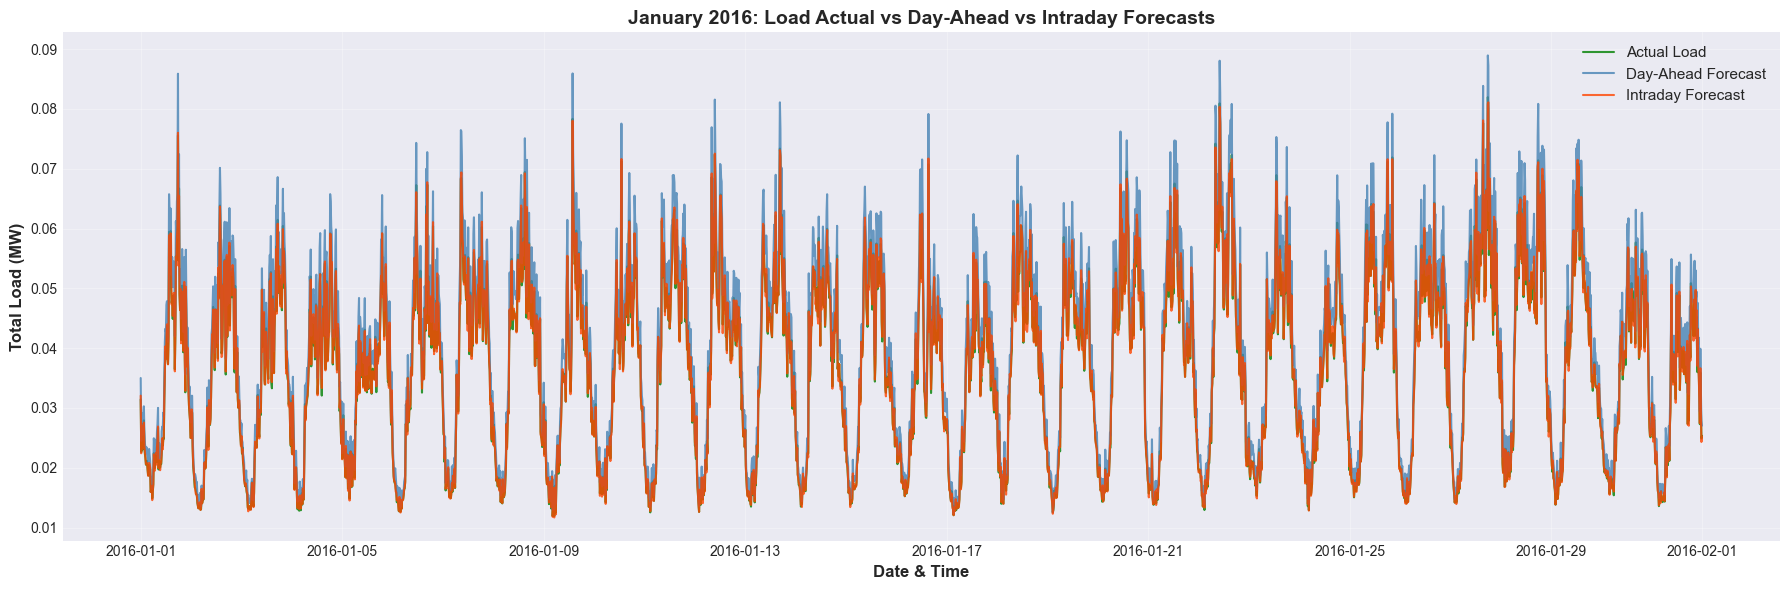


JANUARY 2016 LOAD STATISTICS
Total records: 2976

Actual Load:
  Mean:   0.037 MW
  Median: 0.039 MW
  Min:    0.012 MW
  Max:    0.082 MW

Day-Ahead Forecast:
  Mean:   0.041 MW
  Median: 0.043 MW
  Min:    0.012 MW
  Max:    0.089 MW

Intraday Forecast:
  Mean:   0.037 MW
  Median: 0.039 MW
  Min:    0.012 MW
  Max:    0.081 MW


In [ ]:
# Plot: First Two Weeks of January 2016 - Single Load Unit
load_column = 'LV2.101 Load 9 [H0-C]'

# Filter first two weeks of January (Jan 1-14)
jan_actual = load_actual[(load_actual['datetime'] >= '2016-01-01') & 
                         (load_actual['datetime'] < '2016-01-15')]
jan_da = load_da[(load_da['datetime'] >= '2016-01-01') & 
                 (load_da['datetime'] < '2016-01-15')]
jan_id = load_id[(load_id['datetime'] >= '2016-01-01') & 
                 (load_id['datetime'] < '2016-01-15')]

fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(jan_actual['datetime'], jan_actual[load_column], 
        label='Actual Load', color='green', linewidth=1.5, alpha=0.8)
ax.plot(jan_da['datetime'], jan_da[load_column], 
        label='Day-Ahead Forecast', color='steelblue', linewidth=1.5, alpha=0.8)
ax.plot(jan_id['datetime'], jan_id[load_column], 
        label='Intraday Forecast', color='orangered', linewidth=1.5, alpha=0.8)
ax.set_xlabel('Date & Time', fontsize=12, fontweight='bold')
ax.set_ylabel('Load (MW)', fontsize=12, fontweight='bold')
ax.set_title(f'First Two Weeks of January 2016: {load_column}\nActual vs Day-Ahead vs Intraday Forecasts', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Display statistics
print(f"\n{'='*60}")
print(f"FIRST TWO WEEKS OF JANUARY 2016 - {load_column}")
print(f"{'='*60}")
print(f"Total records: {len(jan_actual)}")
print(f"\nActual Load:")
print(f"  Mean:   {jan_actual[load_column].mean():.6f} MW")
print(f"  Median: {jan_actual[load_column].median():.6f} MW")
print(f"  Min:    {jan_actual[load_column].min():.6f} MW")
print(f"  Max:    {jan_actual[load_column].max():.6f} MW")
print(f"\nDay-Ahead Forecast:")
print(f"  Mean:   {jan_da[load_column].mean():.6f} MW")
print(f"  Median: {jan_da[load_column].median():.6f} MW")
print(f"  Min:    {jan_da[load_column].min():.6f} MW")
print(f"  Max:    {jan_da[load_column].max():.6f} MW")
print(f"\nIntraday Forecast:")
print(f"  Mean:   {jan_id[load_column].mean():.6f} MW")
print(f"  Median: {jan_id[load_column].median():.6f} MW")
print(f"  Min:    {jan_id[load_column].min():.6f} MW")
print(f"  Max:    {jan_id[load_column].max():.6f} MW")
print(f"{'='*60}")
